In [2]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
from firedrake import *
import matplotlib.pyplot as plt

import numpy as np

In [4]:
# from Firedrake Matrix object (output of assemble of bilinear form) to numpy array
def mat2numpy(A):
  return A.petscmat.getValues(range(0, A.petscmat.getSize()[0]), range(0,  A.petscmat.getSize()[1]))
# from Firedrake Cofunction object (output of assemble of linear form) to numpy array
def cofun2numpy(b):
  return b.vector().array()

# Linear solvers in Firedrake / PETSc

We consider the diffusion-reaction problem

\begin{equation*}
\begin{cases}
- \Delta u + u = f & {\rm in} \ \Omega=(0,1)^2, \\
u = 0 & {\rm on} \ \partial\Omega,
\end{cases}
\end{equation*}
with $f(x,y)=(1+2\pi^2)\sin(\pi x)\sin(\pi y)$ and exact solution $u_\text{ex}(x,y)=\sin(\pi x)\sin(\pi y)$.

In [ ]:
N = 10
# Build the mesh
mesh = UnitSquareMesh(N, N, diagonal='left')

# Plot it
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.axis('equal')

# Define a discrete function space
V = FunctionSpace(mesh, 'P', 1)

# Define trial and test functions as belonging to the space
u = TrialFunction(V)
v = TestFunction(V)

# Data
x = SpatialCoordinate(mesh)
u_ex = Function(FunctionSpace(mesh, 'P', 2))    # higher-order FE space to avoid spoiling from interpolation error
u_ex.interpolate(sin(pi*x[0])*sin(pi*x[1]))
f = (1+2*pi*pi)*sin(pi*x[0])*sin(pi*x[1])
bcs = [ DirichletBC(V, Constant(0.0), (1,2,3,4)) ]

# Define the variational problem: bilinear form and rhs
a = dot(grad(u), grad(v)) * dx + u*v*dx
L = f*v*dx

In [185]:
uh = Function(V)

# Define structures to assemble matrix and vector (does not actually perform the assembly: this is done at the first call of a solver)
vpb = LinearVariationalProblem(a, L, uh, bcs=bcs)

In [ ]:
from time import perf_counter

default_solver =  LinearVariationalSolver(vpb)
# NOT NECESSARILY THE ONE REPORTED HERE:
# https://www.firedrakeproject.org/solving-interface.html#default-solver-options

parameters = {'ksp_type': 'preonly', "pc_type": "lu",
                             "pc_factor_mat_solver_type": "mumps"}
direct_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

parameters = {'ksp_type': 'gmres', 'pc_type': 'none',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000}
gmres_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

parameters = {'ksp_type': 'cg', 'pc_type': 'none',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000}
cg_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
default_solver.solve()
print('DEFAULT SOLVER    -   elapsed time =', perf_counter() - t0, 's    -    # iter =', default_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
direct_solver.solve()
print('DIRECT SOLVER     -   elapsed time =', perf_counter() - t0, 's    -    # iter =', direct_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
gmres_solver.solve()
print('GMRES SOLVER      -   elapsed time =', perf_counter() - t0, 's    -    # iter =', gmres_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
cg_solver.solve()
print('CG SOLVER         -   elapsed time =', perf_counter() - t0, 's    -    # iter =', cg_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

In [ ]:
# Plot the numerical solution
fig, ax = plt.subplots()
q = tripcolor(uh, axes=ax)
fig.colorbar(q)

In [ ]:
# check default parameters
from firedrake.petsc import DEFAULT_KSP_PARAMETERS
print(DEFAULT_KSP_PARAMETERS)

# check stop criterion
A = mat2numpy(assemble(a, bcs=bcs))
b = cofun2numpy(assemble(L, bcs=bcs))
u_array = uh.vector()
res = b - (A @ u_array)     # numpy matrix-product operator: @
print('CG SOLUTION  -   relative residual =', np.linalg.vector_norm(res)/np.linalg.vector_norm(b))

# further details on iterative solver
parameters.update({"ksp_monitor": None, 'ksp_monitor_true_residual': None})
cg_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)
uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
cg_solver.solve()

Preconditioning

In [ ]:
parameters = {'ksp_type': 'gmres', 'pc_type': 'none',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000}
gmres_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

parameters.update({'pc_type': 'ilu'})
pgmres_solver =  LinearVariationalSolver(vpb, solver_parameters=parameters)

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
gmres_solver.solve()
print('GMRES SOLVER      -   elapsed time =', perf_counter() - t0, 's    -    # iter =', gmres_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

uh.assign(0)    # initialization to avoid cross-effects from other solvers
t0 = perf_counter()
pgmres_solver.solve()
print('P-GMRES SOLVER    -   elapsed time =', perf_counter() - t0, 's    -    # iter =', pgmres_solver.snes.ksp.getIterationNumber())
print('                  -   error =', errornorm(u_ex, uh, 'H1'))

# Ex.1 - Monolithic Stokes system

### Cavity problem

\begin{equation*}
\begin{cases}
- \Delta \boldsymbol{u} + \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega=(0,1)^2, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{g}_\text{D} & {\rm on} \ \Gamma_4.\\
\boldsymbol{u} = \boldsymbol{0} & {\rm on} \ \partial\Omega\setminus\Gamma_4, \\
\end{cases}
\end{equation*}

with $\boldsymbol{g}_\text{D} = 1\boldsymbol{i}$.

### Points 1-2 : first solution

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


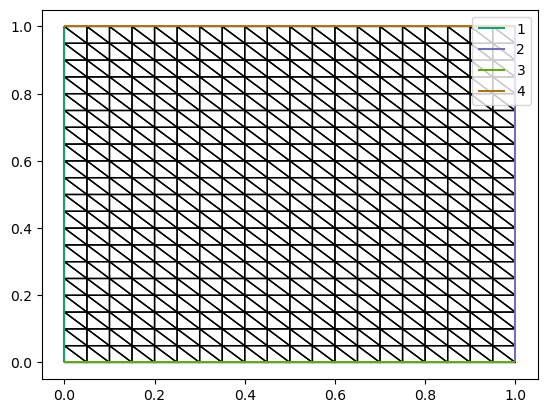

In [10]:
# Build the mesh
n = 20
mesh = UnitSquareMesh(n, n)

fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()

In [11]:
# Function spaces
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])
print('Ndofs - velocity :',V.dim(),', pressure :',Q.dim(),', total :',W.dim())

# Finite element functions
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

Ndofs - velocity : 3362 , pressure : 441 , total : 3803


In [12]:
# Boundary conditions (strong)
bc4 = DirichletBC(W.sub(0), Constant((1., 0.)), 4)
bcRest = DirichletBC(W.sub(0), Constant((0., 0.)), [1,2,3])
bcs = (bc4, bcRest)

# Variational formulation
a = inner(grad(u), grad(v)) * dx - div(v) * p * dx + q * div(u) * dx
L = inner(Constant((0.0,0.0)), v) * dx
  # Dummy rhs (=0) to ensure that the solve recognize a==L as a linear problem

# Null space for fully Dirichlet conditions
nsp = MixedVectorSpaceBasis(
    W, [W.sub(0), VectorSpaceBasis(constant=True)]
)

# Solution (NB: do not use the same name u,v,p,q of the trial/test functions)
from time import perf_counter
wh = Function(W)
vpb = LinearVariationalProblem(a, L, wh, bcs)

firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


In [13]:
parameters = {'ksp_type': 'gmres', 'pc_type': 'ilu',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000}
solver =  LinearVariationalSolver(vpb, nullspace=nsp, solver_parameters=parameters)
t0 = perf_counter()
solver.solve()
print('elapsed time = ', perf_counter() - t0, 's    -    # iter = ', solver.snes.ksp.getIterationNumber())
uh, ph = wh.subfunctions

elapsed time =  0.044859360001282766 s    -    # iter =  120


Text(0.5, 1.0, 'velocity')

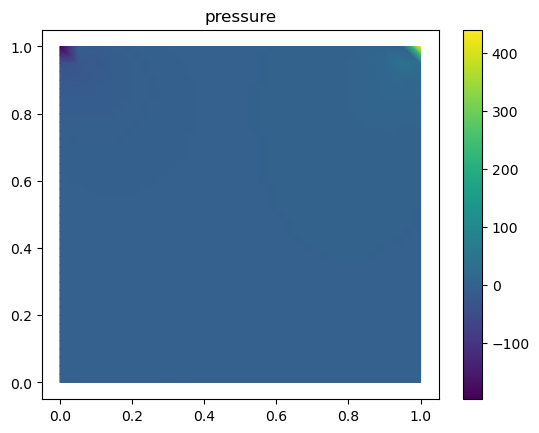

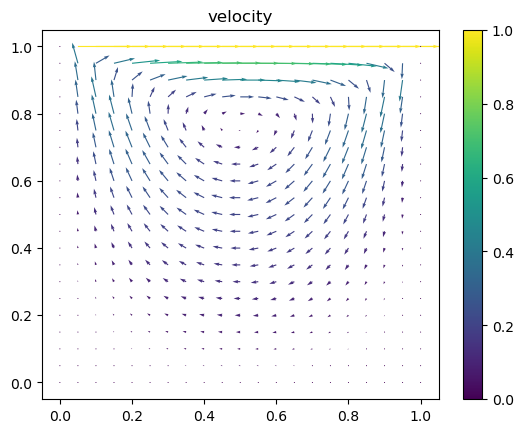

In [9]:
fig, ax = plt.subplots()
col = tripcolor(ph, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
#triplot(mesh, axes=ax)
col = quiver(uh, axes=ax)
plt.colorbar(col)
plt.title('velocity')

### Point 3. Block diagonal preconditioner

Notation for `fieldsplit`
$$
\Sigma = \begin{bmatrix} \Sigma_{00} & \Sigma_{01} \\ \Sigma_{10} & \Sigma_{11} \end{bmatrix} = \begin{bmatrix} A & B^T \\ B & 0 \end{bmatrix}, \qquad P = \begin{bmatrix} P_0 & 0 \\ 0 & P_1 \end{bmatrix} = \begin{bmatrix} A & 0 \\ 0 & \frac{1}{\nu}M_p \end{bmatrix}
$$

$$
\Sigma\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=\begin{bmatrix} \mathbf{F} \\\mathbf{0} \end{bmatrix}
\longrightarrow
P^{-1}\Sigma\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=P^{-1}\begin{bmatrix} \mathbf{F} \\\mathbf{0} \end{bmatrix}
\leftrightarrow
\begin{bmatrix} P_0^{-1}A & P_0^{-1}B^T \\ P_1^{-1}B & 0 \end{bmatrix}\begin{bmatrix} \mathbf{U} \\\boldsymbol{\Pi} \end{bmatrix}=\begin{bmatrix} P_0^{-1}\mathbf{F} \\\mathbf{0} \end{bmatrix}
$$
so for each of the components $P_0, P_1$ of the preconditioner, we need to be able to "apply its inverse" (or an approximation of it).

**N.B.** We **never** actually compute the inverse of a matrix: to "apply the inverse" of a matrix means to solve the associated linear system.

In [14]:
# Create preconditioner form
pc_form = inner(grad(u), grad(v)) * dx + p * q * dx

parameters = {'ksp_type': 'gmres',
              'ksp_rtol': 1.e-8, 'ksp_max_it': 10000,
              "pc_type": "fieldsplit",                                              # use block structure of monolithic matrix
              "pc_fieldsplit_type": "additive",                                     # use a block diagonal preconditioner (taken from pc_form)
              "fieldsplit_0_ksp_type": "preonly", "fieldsplit_0_pc_type": "lu",     # block P0 is "inverted" by LU factorization
              "fieldsplit_1_ksp_type": "preonly", "fieldsplit_1_pc_type": "lu"}     # "inverse" of block P1 is approximated by ILU factorization

wh_PC = Function(W)
vpb = LinearVariationalProblem(a, L, wh_PC, bcs=bcs, aP=pc_form)
solver =  LinearVariationalSolver(vpb, nullspace=nsp, solver_parameters=parameters)
t0 = perf_counter()
solver.solve()
print('elapsed time = ', perf_counter() - t0, 's    -    # iter = ', solver.snes.ksp.getIterationNumber())
uh_PC, ph_PC = wh_PC.subfunctions

elapsed time =  1.1767970049986616 s    -    # iter =  49


Text(0.5, 1.0, 'velocity')

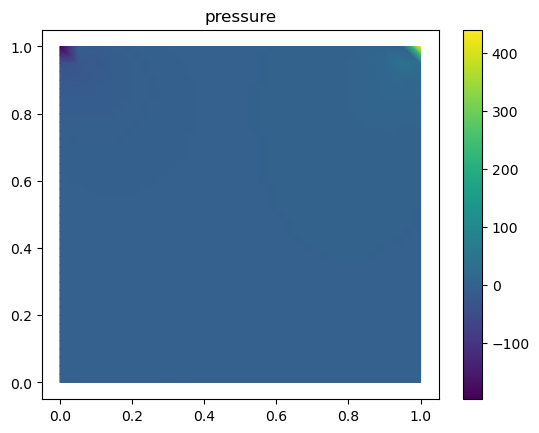

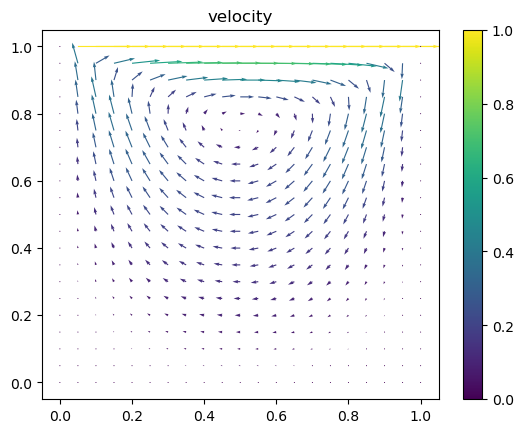

In [15]:
fig, ax = plt.subplots()
col = tripcolor(ph_PC, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
#triplot(mesh, axes=ax)
col = quiver(uh_PC, axes=ax)
plt.colorbar(col)
plt.title('velocity')

### Point 4. Spectra

SPECTRUM OF THE ORIGINAL MATRIX
503 eigenvalues, of which:
    0 equal to 0 (dimension of nullspace)
    62 equal to 1
    61 negative
    380 positive != 1
SPECTRUM OF THE PRECONDITIONED MATRIX
503 eigenvalues, of which:
    0 equal to 0 (dimension of nullspace)
    381 equal to 1 (dim(Vh)-dim(Qh) = 381 )
    61 negative (dim(Qh) = 61 )
    61 positive != 1 (dim(Qh) = 61 )


/home/aless/.local/share/mamba/envs/firedrake/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/aless/.local/share/mamba/envs/firedrake/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


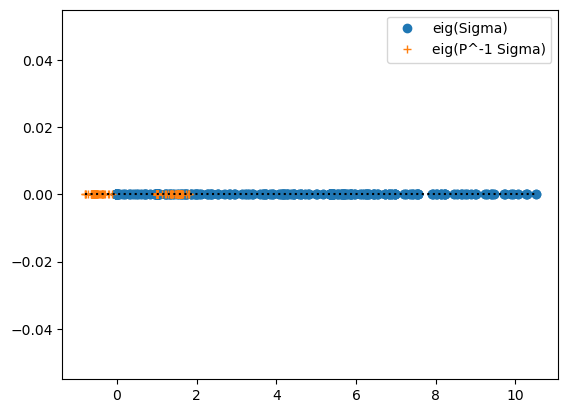

In [16]:
# Small problem to investigate eigenvalues
n=5
mesh = UnitSquareMesh(n, n, diagonal='crossed')
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

x = SpatialCoordinate(mesh)
bcs = ( DirichletBC(W.sub(0), Constant((0.,0.)), [3, 4]),
        DirichletBC(W.sub(0), as_vector((x[1]*(1-x[1]),0.0)), 1)
       )
# IN THIS INVESTIGATION, WE CONSIDER A CASE WITH A NEUMANN BOUNDARY,
# TO (TEMPORARILY) AVOID THE ISSUE OF THE NULLSPACE BEING NON-TRIVIAL.
# The cavity problem can be restored with the following BC's:
# counting the eigenvalues in the cluster is slightly more complex in such case.
# bc4 = DirichletBC(W.sub(0), Constant((1., 0.)), 4)
# bcRest = DirichletBC(W.sub(0), Constant((0., 0.)), [1,2,3])
# bcs = (bc4, bcRest)

# Problem matrix
a = inner(grad(u), grad(v)) * dx - div(v) * p * dx - q * div(u) * dx
L = inner(Constant((0.0,0.0)), v) * dx
Sigma = assemble(a, bcs=bcs).M.values

# Preconditioner
myPCform = inner(grad(u), grad(v)) * dx + p * q * dx
P = assemble(myPCform, bcs=bcs).M.values

ll, vv = np.linalg.eig(Sigma)
true_nullspace = vv[:, abs(ll)<1e-14]

import scipy as sp
prec_ll, prec_vv = sp.linalg.eig(Sigma, P)
true_nullspace = prec_vv[:, abs(prec_ll)<1e-14]

np.set_printoptions(precision=2)
np.set_printoptions(linewidth=400)
np.set_printoptions(suppress=True)

plt.plot(ll, np.imag(ll), marker='o', linestyle='none', label='eig(Sigma)')
plt.plot(prec_ll, np.imag(prec_ll), marker='+', linestyle='none', label='eig(P^-1 Sigma)')
plt.plot([1, 1], [ min([min(np.imag(ll)), min(np.imag(prec_ll))]), max([max(np.imag(ll)), max(np.imag(prec_ll))]) ], 'k:')
plt.plot([0, 0], [ min([min(np.imag(ll)), min(np.imag(prec_ll))]), max([max(np.imag(ll)), max(np.imag(prec_ll))]) ], 'k:')
plt.plot([ min([min(np.real(ll)), min(np.real(prec_ll))]), max([max(np.real(ll)), max(np.real(prec_ll))]) ], [0, 0], 'k:')
plt.legend()

tol = 1e-10
print('SPECTRUM OF THE ORIGINAL MATRIX')
print(ll.size, 'eigenvalues, of which:')
print('   ', np.sum(abs(ll)<tol), 'equal to 0 (dimension of nullspace)')
print('   ', np.sum(abs(ll-1)<tol), 'equal to 1')
print('   ', np.sum(ll < 0), 'negative')
print('   ', np.sum(ll > 0)-np.sum(abs(ll-1)<tol), 'positive != 1')
print('SPECTRUM OF THE PRECONDITIONED MATRIX')
print(prec_ll.size, 'eigenvalues, of which:')
print('   ', np.sum(abs(prec_ll)<tol), 'equal to 0 (dimension of nullspace)')
print('   ', np.sum(abs(prec_ll-1)<tol), 'equal to 1 (dim(Vh)-dim(Qh) =', V.dim()-Q.dim(),')')
print('   ', np.sum(prec_ll < -tol), 'negative (dim(Qh) =', Q.dim(),')')
print('   ', np.sum(prec_ll > tol)-np.sum(abs(prec_ll-1)<tol), 'positive != 1 (dim(Qh) =', Q.dim(),')')